## **Laboratorio 02: Regresión Líneal Múltiple**

## Predicción de Tiempo de Juego en Steam Games

1. Importaciones y Drive

In [33]:
# Ejercicio de programación Regresión Lineal Multiple
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


2. Cargar Datos (Regla de Pandas)

In [34]:
# Cargar datos con Pandas
ruta = '/content/gdrive/MyDrive/Inteligencia Artificial 1 - Kevin/Laboratorios/Laboratorio 02 - Regresion Lineal Multivariable/games_march2025_cleaned.csv'
df = pd.read_csv(ruta, low_memory=False, on_bad_lines='skip')

# Limpieza rápida
df_numerico = df.select_dtypes(include=[np.number, bool]).copy().astype(float)
df_limpio = df_numerico.fillna(0)

# Separar X e Y
columnas_a_excluir = ['average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks']
columnas_x = [col for col in df_limpio.columns if col not in columnas_a_excluir][:25]

X = df_limpio[columnas_x].values
y = df_limpio['average_playtime_forever'].values
m = len(y)

print(f"Total de datos (m): {m}")
print(f"Total de predictoras (n): {len(columnas_x)}\n")

print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

Total de datos (m): 89618
Total de predictoras (n): 20

  X[:,0] X[:, 1]         y
--------------------------
     730       0     33189
  578080       0         0
     570       0     43031
  271590      17     19323
  359550      17     14204
     440       0         0
  105600       0         0
  252490       0     21195
    4000       0     10987
 1172470       0      9450


3. Normalizacion

In [35]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Evita división por cero
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizamos X
X_norm, mu, sigma = featureNormalize(X)

# Añadimos la columna de unos al principio
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.3f}{:8.3f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

  X[:,0] X[:, 1]         y
--------------------------
   1.000  -1.806     33189
   1.000  -1.177         0
   1.000  -1.807     43031
   1.000  -1.511     19323
   1.000  -1.415     14204
   1.000  -1.807         0
   1.000  -1.692         0
   1.000  -1.532     21195
   1.000  -1.803     10987
   1.000  -0.528      9450


4. Funciones del Descenso

In [37]:
def computeCostMulti(X, y, theta):
    m = len(y)
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

5. Ejecución y Gráfica

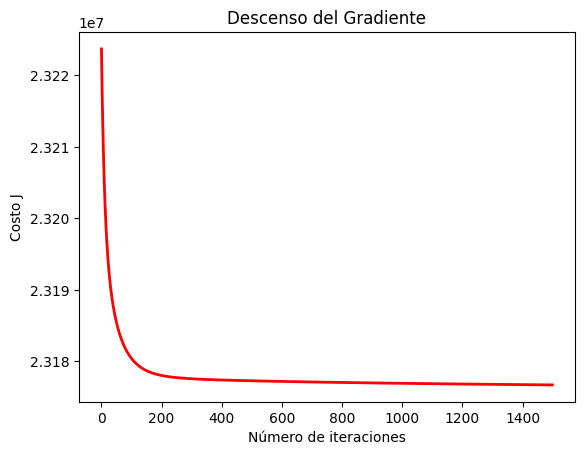

theta calculado por el descenso por el gradiente: [114.91184895 -77.39268289  15.05383675  34.18049321  14.71962564
   0.68269024 -24.83916753 -23.30413766   6.00385119   7.19979585
 -21.71305002  -0.55960487  -2.33981464 140.59388305  49.88276551
 123.95852253   7.91901793  35.79965657  37.55666754  85.12642119
 -13.42891555]


In [38]:
# Elegir algun valor para alpha (probar varias opciones)
alpha = 0.01
num_iters = 1500

# Inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2, color='red')
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Descenso del Gradiente')
plt.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

6. Inferencia (Predicción) - adivinamos el futuro con un juego **inventado**

In [42]:
# Estimar el tiempo de juego para un videojuego AAA
juego_nuevo = mu.copy()
juego_nuevo[0] = 60.00  # Precio simulado
juego_nuevo[1] = 50000  # Recomendaciones simuladas

# Normalizamos
juego_norm = (juego_nuevo - mu) / sigma
juego_listo = np.concatenate([[1], juego_norm])

prediccion_tiempo = np.dot(juego_listo, theta)
print(f"Tiempo de juego estimado (Descenso por el Gradiente): {prediccion_tiempo:.2f} hrs")

Tiempo de juego estimado (Descenso por el Gradiente): 436448.48 hrs


**7. Ecuación de la Normal**

In [40]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

8. Ejecución Ecuación Normal e Inferencia

In [41]:
# Calcula los parametros con la ecuación de la normal (sin normalizar)
X_orig = df_limpio[columnas_x].values
X_orig_con_unos = np.concatenate([np.ones((m, 1)), X_orig], axis=1)

theta_normal = normalEqn(X_orig_con_unos, y)
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_normal)))

# Estimar con la Ecuación de la Normal
juego_nuevo_normal = np.concatenate([[1], juego_nuevo])
prediccion_normal = np.dot(juego_nuevo_normal, theta_normal)

print(f"Tiempo de juego estimado (Ecuación Normal): {prediccion_normal:.2f} hrs")

Theta calculado a partir de la ecuación de la normal: [ 1.14724033e+02 -8.31550000e-05  7.48543426e+00  2.51427152e+00
  8.82643299e-01  3.51865086e+01 -6.19775239e+01 -6.83756386e+01
  1.97804521e-01  4.22183135e-02 -6.16159617e-03  9.06292817e-01
 -2.05646217e+00  1.81847582e-02  2.13321569e-02  7.50578081e+00
 -2.58109713e-04  9.02403948e-01 -1.02570401e-02  3.80836203e+00
 -4.58784899e-03]
Tiempo de juego estimado (Ecuación Normal): 374523.03 hrs
